In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Convolution2D, MaxPooling2D, Dropout, Flatten, Dense, Conv2D, BatchNormalization, Activation
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import cv2
import pandas as pd
import ntpath
import random

In [ ]:
from google.colab import files
'upload kaggle.json'
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hugobrowning","key":"b777e047251a808a31633108d7a3d6dc"}'}

In [ ]:
os.makedirs(
    "/root/.kaggle",
    exist_ok =True
)

!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!pip install kaggle --quiet

mv: cannot stat 'kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d shahriar26s/banana-ripeness-classification-dataset -p /content/kaggle_banana
!unzip -q /content/kaggle_banana/*.zip -d /content/kaggle_banana

Dataset URL: https://www.kaggle.com/datasets/shahriar26s/banana-ripeness-classification-dataset
License(s): apache-2.0
100% 221M/221M [00:02<00:00, 94.5MB/s]



In [ ]:
!pip3 install --upgrade kaggle --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 10.6 MB/s eta 0:00:00


In [ ]:
for root, dirs, files in os.walk("/content/kaggle_banana"):
    level = root.replace("/content/kaggle_banana", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files:
            print(f"{indent}  {f}")
        if len(files) > 3:
            print(f"{indent}  ... ({len(files)} files total)")

kaggle_banana/
  banana-ripeness-classification-dataset.zip
  Banana Ripeness Classification Dataset/
    test/
      unripe/
      ripe/
      overripe/
      rotten/
    train/
      unripe/
      ripe/
      overripe/
      rotten/
    valid/
      unripe/
      ripe/
      overripe/
      rotten/


In [ ]:
base_dir = "/content/kaggle_banana/Banana Ripeness Classification Dataset"

splits=[
    "train",
    "valid",
    'test'
]
classes = [
    "unripe",
    'ripe',
    'overripe',
    'rotten'
]

for j in splits:
  print(f"--- {j} ---")
  for i in classes:
    folder = os.path.join(base_dir,j, i)
    count=len(os.listdir(folder))
    print(f" {i}: {count} images")

--- train ---
 unripe: 1902 images
 ripe: 3522 images
 overripe: 2349 images
 rotten: 4020 images
--- valid ---
 unripe: 167 images
 ripe: 339 images
 overripe: 229 images
 rotten: 388 images
--- test ---
 unripe: 110 images
 ripe: 154 images
 overripe: 113 images
 rotten: 185 images


In [ ]:
import tensorflow as tf

class Banana_Ripeness_classifier:
  def __init__(self, img_size=(224, 224), classes = None, base_dir = None):
    self.img_size=img_size
    if classes is not None:
      self.classes = classes
    elif classes is None:
      self.classes = [
          'unripe',
          'ripe',
          'overripe',
          'rotten'
      ]

    if base_dir is not None:
      self.base_dir = base_dir
    elif base_dir is None:
      self.base_dir='/content/kaggle_banana/Banana Ripeness Classification Dataset'

    self.image_list_names=[
        '.jpeg',
        '.png',
        '.jpg'
    ]


  def build_cnn(self, input_shape=None, num_classes = None, fine_tune_at =0):
    if input_shape is None:
      input_shape = (self.img_size[0], self.img_size[1], 3)
    if num_classes is None:
      num_classes=len(self.classes)

    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape = input_shape)

    base_model.trainable=True

    for j in base_model.layers[:fine_tune_at]:
      j.trainable=False

    x=base_model.output
    x=GlobalAveragePooling2D()(x)
    x=Dense(
        256,
        activation = 'relu'
    )(x)
    x=Dropout(0.5)(x)
    pred=Dense(
      num_classes,
      activation = 'softmax'
    )(x)

    model=Model(
        inputs=base_model.input,
        outputs=pred
    )
    return model

  def segment_banana(self, img_path):
    img = cv2.imread(img_path)

    if img is None:
      print(f"Error, failed to read image, image path is: ---- {img_path}")
      return None

    gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary=cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
      largest_contour=max(contours, key = cv2.contourArea)

      x, y, w, h=cv2.boundingRect(largest_contour)

      padding=10

      x_padded = max(0, x-padding)
      y_padded = max(0, y-padding)
      w_padded=min(img.shape[1] - x_padded, w+2*padding)
      h_padded=min(img.shape[0] - y_padded, h+2*padding)

      segmented_img= img[
          y_padded:y_padded + h_padded,
          x_padded:x_padded + w_padded
      ]

      return cv2.resize(
          segmented_img,
          self.img_size
      )

  def process_data(self, input_base_dir, output_base_dir):
    splits=[
        "train",
        "valid",
        'test'
    ]

    for s in splits:
      input_subset_name=os.path.join(
          input_base_dir,
          s
      )
      output_subset_name = os.path.join(
          output_base_dir,
          s
      )

      exist=os.path.exists(input_subset_name)

      if not exist:
        print(f"Input path not found: {input_subset_name}")

      for cn in self.classes:
        input_class_path= os.path.join(input_subset_name, cn)
        output_class_path =os.path.join(output_subset_name, cn)

        os.makedirs(
            output_class_path,
            exist_ok=True
        )

        if not os.path.isdir(input_class_path):
          continue

        print(f'Processing Images in: {input_class_path}')

        for image_name in os.listdir(input_class_path):
          image_path =os.path.join(input_class_path, image_name)

          if not os.path.isfile(image_path) or not image_name.lower().endswith(tuple(self.image_list_names)):
            continue

          segmented_img=self.segment_banana(image_path)

          if segmented_img is not None:
            output_image_path = os.path.join(output_class_path, image_name)

            cv2.imwrite(
                output_image_path,
                segmented_img
            )

  def load_data_generators(self, batch_size=32):
    train_gen=ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range = 0.15,
        horizontal_flip = True,
        brightness_range = [
            0.8,
            1.2
        ]
    )

    val_test_gen = ImageDataGenerator(
        rescale=1./255
    )

    train_data=train_gen.flow_from_directory(
        os.path.join(
            self.base_dir,
            'train'
        ),
        target_size = self.img_size,
        batch_size = batch_size,
        class_mode='categorical',
        classes = self.classes
    )

    val_data = val_test_gen.flow_from_directory(
        os.path.join(
            self.base_dir,
            'valid'
        ),
        target_size=self.img_size,
        batch_size = batch_size,
        class_mode = 'categorical',
        classes =self.classes
    )

    test_data=val_test_gen.flow_from_directory(
        os.path.join(
            self.base_dir,
            'test'
        ),
        target_size = self.img_size,
        batch_size = batch_size,
        class_mode = 'categorical',
        classes=self.classes,
        shuffle=False
    )

    return train_data, val_data, test_data

  def build_callbacks(self, drive_path, history_log, history_save_path):
    from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, LambdaCallback
    import pickle

    early_stopping=EarlyStopping(
        monitor = 'val_loss',
        patience = 8,
        mode = 'min',
        verbose =1,
        restore_best_weights=True
    )

    model_checkpoint = ModelCheckpoint(
        filepath =os.path.join(
            drive_path,
            'final_banana_ripeness_model.keras'
        ),
        monitor = 'val_accuracy',
        mode ='max',
        save_best_only=True,
        save_weights_only=False,
        verbose =1
    )

    def save_history_callback(epoch, logs):
      for k in history_log:
        if k in logs:
          history_log[k].append(logs[k])
        with open(history_save_path, 'wb') as f:
          pickle.dump(history_log, f)

    lambda_callback=LambdaCallback(
        on_epoch_end =save_history_callback
    )

    reduce_lr =ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.2,
        patience = 3,
        min_lr = 1e-6,
        verbose =1
    )

    callbacks = [
        early_stopping,
        model_checkpoint,
        lambda_callback,
        reduce_lr
    ]

    return callbacks

  def train(self, model, train_data, val_data, class_weights, drive_path, epochs):
      history_log = {
          'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []
      }
      history_save_path = os.path.join(drive_path, 'training_history.pkl')
      callbacks = self.build_callbacks(drive_path, history_log, history_save_path)

      print("\n--- Training Model ---")
      history = model.fit(
          train_data,
          epochs=epochs,
          validation_data=val_data,
          class_weight=class_weights,
          callbacks=callbacks,
          verbose=1
      )
      self.model = max_pool_grad_grad_eager_fallback
      print("Model training complete.")
      return history

  def load_model(self, model_path):
    self.model = tf.keras.models.load_model(model_path)
    print(f"Model Loaded from: {model_path}")
    return self.model

  def evaluate_model(self, test_data):
    print("\n --- Evaluating on test set ----")
    test_loss, test_accuracy = self.model.evaluate(test_data, verbose = 1)
    print(f"\n Test Accuracy: {np.round(test_accuracy, 4)} || Test Loss: {np.round(test_loss, 4)}")

    return test_loss, test_accuracy

  def plot_training_history(self, history_path):
    import pickle

    with open(history_path, 'rb') as f:
      history_data = pickle.load(f)

    print(f"Available Keys: {list(history_data.keys())}")

    fig, axes = plt.subplots(
        1,
        2,
        figsize = (12, 4),
        constrained_layout = True
    )
    axes=axes.flatten()

    axes[0].plot(history_data['accuracy'], label='Train Accuracy')
    axes[0].plot(history_data['val_accuracy'], label='Val Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history_data['loss'], label='Train Loss')
    axes[1].plot(history_data['val_loss'], label='Val Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle('MobileNetV2 Training History', fontsize=14)
    plt.show()

  def plot_confusion_matrix(self, test_data):
    from sklearn.metrics import confusion_matrix, classification_report
    import seaborn as sns

    test_data.reset()
    y_pred = np.argmax(self.model.predict(test_data, verbose=1), axis=1)
    y_true = test_data.classes

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=self.classes,
                yticklabels=self.classes)
    plt.title('MobileNetV2 — Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=self.classes))

  def predict_sample_grid(self, test_data, num_samples=9):
    import random

    class_buckets = {i: [] for i in range(len(self.classes))}

    test_data.reset()
    for images, labels in test_data:
        true_idx = np.argmax(labels, axis=1)
        pred_idx = np.argmax(
            self.model.predict(images, verbose=0), axis=1
        )
        for j in range(len(images)):
            cls = true_idx[j]
            if len(class_buckets[cls]) < 4:
                class_buckets[cls].append({
                    'image': images[j],
                    'true': true_idx[j],
                    'pred': pred_idx[j]
                })

        if all(len(v) >= 2 for v in class_buckets.values()):
            break
    final_samples = []

    for cls_idx in range(len(self.classes)):
        if class_buckets[cls_idx]:
            final_samples.append(class_buckets[cls_idx].pop(0))

    remaining = []
    for cls_idx in range(len(self.classes)):
        remaining.extend(class_buckets[cls_idx])

    random.shuffle(remaining)
    final_samples.extend(remaining[:num_samples - len(final_samples)])
    random.shuffle(final_samples)

    cols = 3
    rows = (len(final_samples) + cols - 1) // cols
    plt.figure(figsize=(12, 4 * rows))

    for i, sample in enumerate(final_samples):
        plt.subplot(rows, cols, i + 1)
        plt.imshow((sample['image'] * 255).astype(np.uint8))
        true_class = self.classes[sample['true']]
        pred_class = self.classes[sample['pred']]
        color = "green" if true_class == pred_class else "red"
        plt.title(
            f"True: {true_class}\nPred: {pred_class}",
            color=color,
            fontsize=11
        )
        plt.axis('off')

    plt.suptitle(
        "Sample Predictions (Green=Correct, Red=Wrong)",
        fontsize=13,
        y=1.01
    )
    plt.tight_layout()
    plt.show()

  def predict_single_image(self, img_path):
    from tensorflow.keras.preprocessing import image as keras_image

    img=keras_image.load_img(img_path, target_size=self.img_size)
    x=keras_image.img_to_array(img)
    x=np.expand_dims(
        x,
        axis= 0
    )
    x=x/255
    preds = self.model.predict(
        x,
        verbose = 0
    )
    pred_idx = np.argmax(preds, axis = 1)[0]
    confidence=float(preds[0][pred_idx])

    return {
        "Class": self.classes[pred_idx],
        'Confidence': confidence,
        "All_Probabilities": {
            cls: float(preds[0][i])
            for i, cls in enumerate(self.classes)
        }
    }

print("BananaRipenessClassifier class defined.")

BananaRipenessClassifier class defined.


In [ ]:
drive_path = '/content/drive/MyDrive/banana_ripeness_model_results'
file_path = os.path.join(drive_path, 'classifier.py')

with open(file_path, 'r') as f:
    content = f.read()

print("Content of classifier.py in Google Drive:")
print(content)

Content of classifier.py in Google Drive:

import tensorflow as tf

class Banana_Ripeness_classifier:
  def __init__(self, img_size=(224, 224), classes = None, base_dir = None):
    self.img_size=img_size
    if classes is not None:
      self.classes = classes
    elif classes is None:
      self.classes = [
          'unripe',
          'ripe',
          'overripe',
          'rotten'
      ]

    if base_dir is not None:
      self.base_dir = base_dir
    elif base_dir is None:
      self.base_dir='/content/kaggle_banana/Banana Ripeness Classification Dataset'

    self.image_list_names=[
        '.jpeg',
        '.png',
        '.jpg'
    ]


  def build_cnn(self, input_shape=None, num_classes = None, fine_tune_at =0):
    if input_shape is None:
      input_shape = (self.img_size[0], self.img_size[1], 3)
    if num_classes is None:
      num_classes=len(self.classes)

    base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape = input_shap

In [ ]:
classifier = Banana_Ripeness_classifier()
model = classifier.build_cnn(fine_tune_at=-20)

optimizer = 'adam'
metrics = ['accuracy']
loss = 'categorical_crossentropy'

model.compile(
    optimizer=optimizer,
    metrics=metrics,
    loss = loss
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 1,535,044 (5.86 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [ ]:
print(f"Number of trainable layers: {len(model.trainable_weights)}")

Number of trainable layers: 25


In [ ]:
import gc
gc.collect()
tf.keras.backend.clear_session()

In [ ]:
train_data, val_data, test_data=classifier.load_data_generators(
    batch_size=32
)

Found 11793 images belonging to 4 classes.
Found 1123 images belonging to 4 classes.
Found 562 images belonging to 4 classes.


In [ ]:
from sklearn.utils import compute_class_weight

train_labels =train_data.classes

class_weights_array=compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y=train_labels
)

In [ ]:
class_weights = dict(enumerate(class_weights_array))
print(f" Class Weights: {class_weights}")

 Class Weights: {0: np.float64(1.5500788643533123), 1: np.float64(0.8370954003407155), 2: np.float64(1.2551085568326947), 3: np.float64(0.7333955223880597)}


In [ ]:
drive_path = '/content/drive/MyDrive/banana_ripeness_model_results'

classifier.train(
    model=model,
    train_data=train_data,
    val_data=val_data,
    class_weights=class_weights,
    drive_path=drive_path,
    epochs=10
)


--- Training Model ---
Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9821 - loss: 0.0591
Epoch 1: val_accuracy improved from None to 0.97150, saving model to /content/drive/MyDrive/banana_ripeness_model_results/final_banana_ripeness_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/banana_ripeness_model_results/final_banana_ripeness_model.keras
369/369 ━━━━━━━━━━━━━━━━━━━━ 506s 1s/step - accuracy: 0.9791 - loss: 0.0616 - val_accuracy: 0.9715 - val_loss: 0.2624 - learning_rate: 0.0010
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9746 - loss: 0.0661
Epoch 2: val_accuracy improved from 0.97150 to 0.97418, saving model to /content/drive/MyDrive/banana_ripeness_model_results/final_banana_ripeness_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/banana_ripeness_model_results/final_banana_ripeness_model.keras
369/369 ━━━━━━━━━━━━━━━━━━━━ 484s 1s/step - accuracy: 0.9769 - loss: 0.0623 - val_accuracy: 0.9742 - val_

In [ ]:
print(classifier)

In [ ]:
import gc
import tensorflow as tf

try:
  del train_data, val_data
except NameError:
  pass

gc.collect()
tf.keras.backend.clear_session()
print('Memory Has Been Cleared')
!nvidia-smi --query-gpu=memory.used,memory.free --format=csv

Memory Has Been Cleared
/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
classifier=Banana_Ripeness_classifier()

classifier.load_model(
    '/content/drive/MyDrive/banana_ripeness_model_results/final_banana_ripeness_model.keras'
)

Model Loaded from: /content/drive/MyDrive/banana_ripeness_model_results/final_banana_ripeness_model.keras


<Functional name=functional, built=True>

In [ ]:
_, _, test_data =classifier.load_data_generators(
    batch_size = 32
)
print('Test Generator is Ready')

Found 11793 images belonging to 4 classes.
Found 1123 images belonging to 4 classes.
Found 562 images belonging to 4 classes.
Test Generator is Ready


Available Keys: ['loss', 'accuracy', 'val_loss', 'val_accuracy']


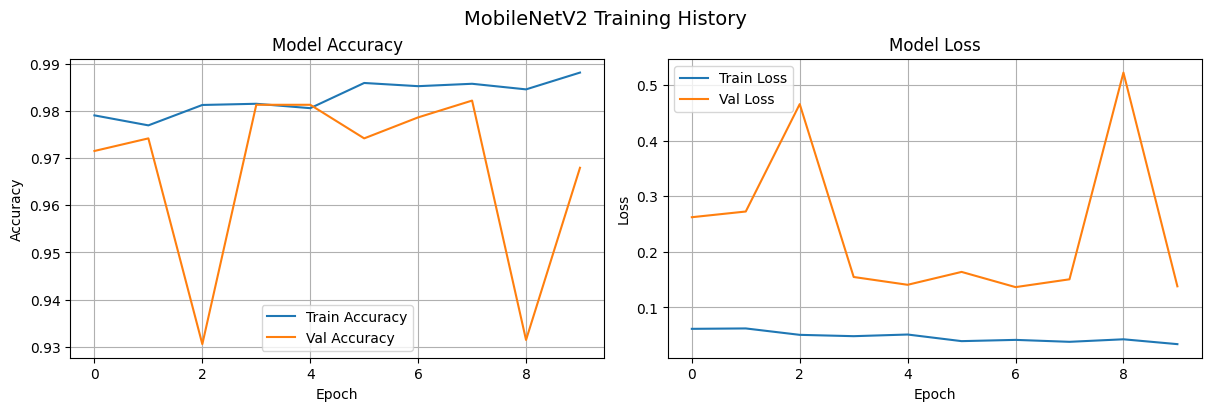

In [ ]:
classifier.plot_training_history(
    '/content/drive/MyDrive/banana_ripeness_model_results/training_history.pkl'
)

In [ ]:
classifier.evaluate_model(test_data)


 --- Evaluating on test set ----
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 748ms/step - accuracy: 0.9875 - loss: 0.0860

 Test Accuracy: 0.9875 || Test Loss: 0.086


(0.08599687367677689, 0.9875444769859314)

18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 814ms/step


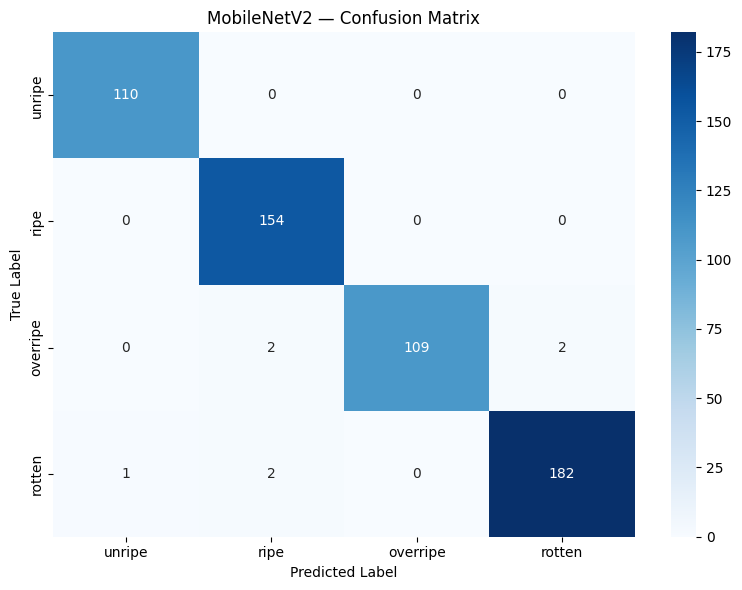


Classification Report:
              precision    recall  f1-score   support

      unripe       0.99      1.00      1.00       110
        ripe       0.97      1.00      0.99       154
    overripe       1.00      0.96      0.98       113
      rotten       0.99      0.98      0.99       185

    accuracy                           0.99       562
   macro avg       0.99      0.99      0.99       562
weighted avg       0.99      0.99      0.99       562



In [ ]:
classifier.plot_confusion_matrix(test_data)

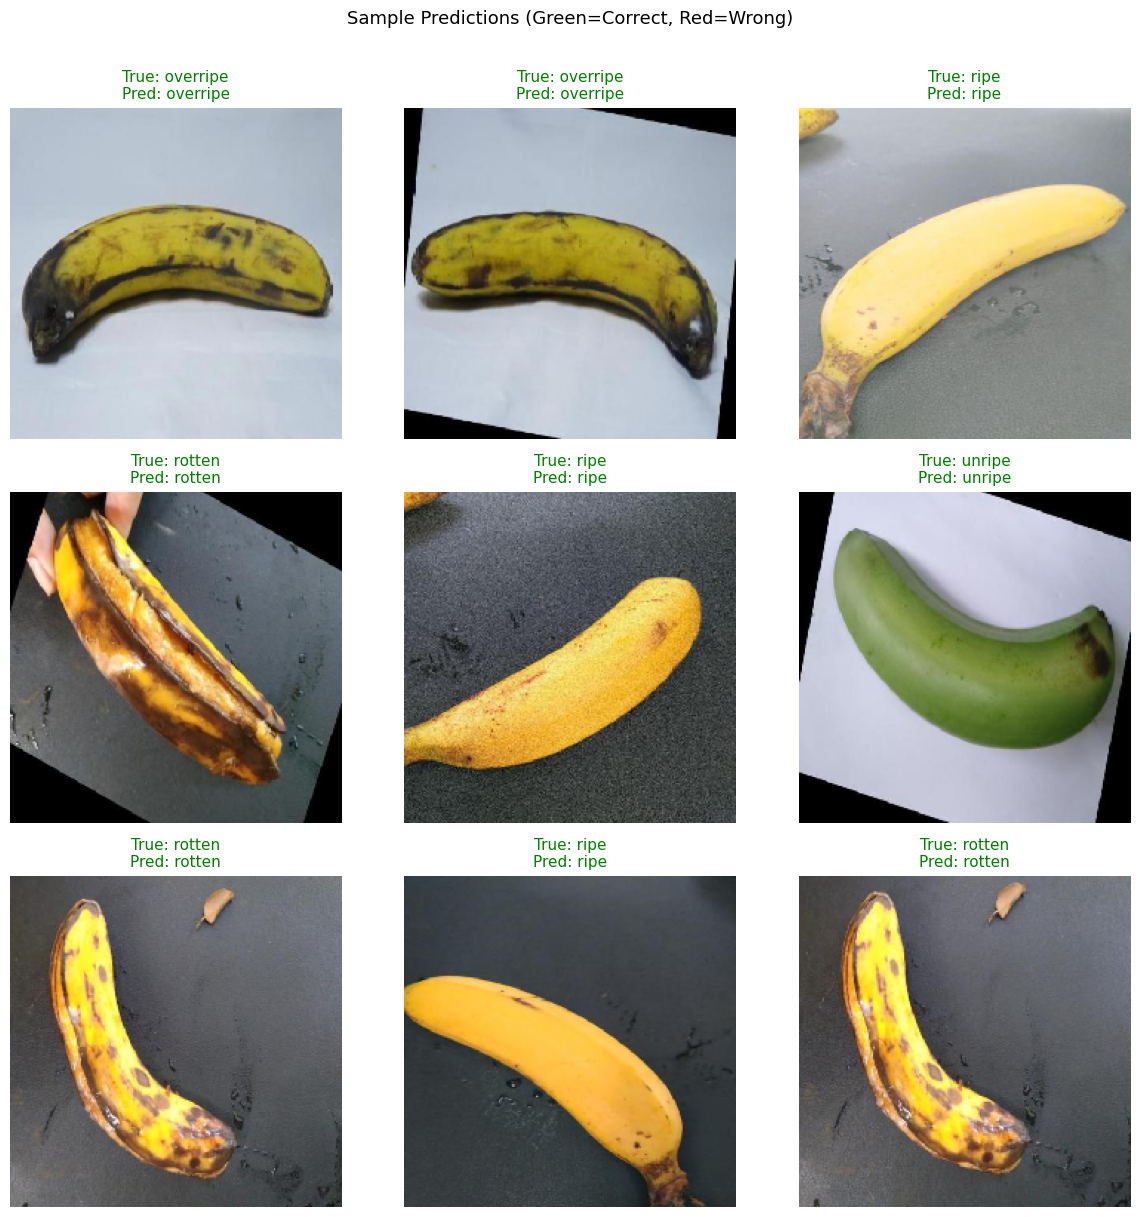

In [ ]:
classifier.predict_sample_grid(test_data)

In [ ]:
import os

drive_path = '/content/drive/MyDrive/banana_ripeness_model_results'
files = os.listdir(drive_path)
print("Files on Drive:")
for f in files:
    size = os.path.getsize(os.path.join(drive_path, f))
    print(f"  {f} — {size/1e6:.2f} MB")

Files on Drive:
  training_history.pkl — 0.00 MB
  final_banana_ripeness_model.keras — 23.23 MB


In [ ]:
with open(os.path.join(drive_path, 'classifier.py'), 'w') as f:
    f.write(class_code)

print("classifier.py saved to Drive with updated content.")

classifier.py saved to Drive with updated content.


In [ ]:
import os

drive_path = '/content/drive/MyDrive/banana_ripeness_model_results'

print("Files confirmed on Drive:")
for f in os.listdir(drive_path):
    if os.path.isfile(os.path.join(drive_path, f)):
        size = os.path.getsize(os.path.join(drive_path, f))
        print(f"  {f} — {size/1e6:.2f} MB")

Files confirmed on Drive:
  classifier.py — 0.01 MB
  training_history.pkl — 0.00 MB
  final_banana_ripeness_model.keras — 23.23 MB
